In [1]:
import os
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stat
import pingouin as pg
import warnings
warnings.filterwarnings('ignore')

In [2]:
os.chdir('exp1_data')

In [77]:
experiment_df = pd.DataFrame()
demographic_df = pd.DataFrame()
for id in os.listdir():
    data = json.load(open(id))          
    experiment  = pd.DataFrame(data["trials"])
    demographic = pd.DataFrame([data["demographics"]])
    experiment_df = pd.concat([experiment_df, experiment], ignore_index=True)
    demographic_df = pd.concat([demographic_df, demographic], ignore_index=True)

# survey

In [5]:
demographic_df[['coverstory', 'sound_awareness', 'speed_awareness']].value_counts()

coverstory  sound_awareness                             speed_awareness
children    Yes, sometimes louder and sometimes softer  Yes                30
            Yes, sometimes louder                       Yes                11
            No change noticed                           Yes                 1
            Yes, sometimes louder and sometimes softer  No                  1
Name: count, dtype: int64

## exclusion

In [6]:
drop = []
sub_id = experiment_df['subject_id'].unique()

for i in sub_id:
    sub_demo = demographic_df[demographic_df['subject_id'] == i]
    if sub_demo['coverstory'].values[0] != 'children':
        drop.append(i)
        
    sub_df = experiment_df[experiment_df['subject_id'] == i]
    if len(sub_df) != 162:
        drop.append(i)
    if len(sub_df[(sub_df['chargeSpeed'] == 9) & (sub_df['response'] == 'play')]) > len(sub_df[(sub_df['chargeSpeed'] == 1.5) & (sub_df['response'] == 'play')]):
        drop.append(i)

In [7]:
drop_set = set(drop)
kept_sub = [id for id in sub_id if id not in drop_set]

In [8]:
drop

[]

# main analysis - across sound conditions

In [9]:
experiment_df.head()

,id,trial_number,trialID,soundCondition,chargeSpeed,leftColor,ISI_ms,repetition,response,is_fight,response_rt,confidence,confidence_rt,subject_id
0,59948cbdcf1d1700016efa45,1,50781782-fbf2-4226-a593-5173be906638,higher,4.00,black,514.3,4,play,0,1240,62.856120,2379,59948cbdcf1d1700016efa45
1,59948cbdcf1d1700016efa45,2,059f8cfb-52c8-47fd-8d26-b0fec58eafae,same,9.00,grey,483.3,8,play,0,3156,43.427083,2650,59948cbdcf1d1700016efa45
2,59948cbdcf1d1700016efa45,3,59df47e5-696a-407f-aa33-94dab9b3e492,higher,2.75,grey,474.1,8,play,0,1409,56.569661,14981,59948cbdcf1d1700016efa45
3,59948cbdcf1d1700016efa45,4,0a4312a1-7156-4c68-9698-0f1495558bee,higher,5.25,grey,497.9,8,fight,1,1222,43.333333,1795,59948cbdcf1d1700016efa45
4,59948cbdcf1d1700016efa45,5,a57832a0-0b6a-4bdf-a636-adf042cd3fcc,same,7.75,grey,485.7,6,play,0,4137,35.611328,3262,59948cbdcf1d1700016efa45


In [10]:
ids = experiment_df['id'].unique()

## judgement

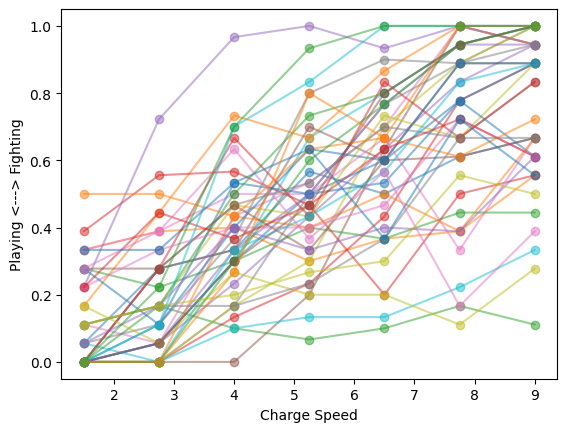

In [11]:
for id in ids:
    df = experiment_df[experiment_df['id'] == id]
    mean_rating_per_speed = pd.DataFrame(df.groupby('chargeSpeed')['is_fight'].mean().reset_index())
    plt.plot(mean_rating_per_speed['chargeSpeed'], mean_rating_per_speed['is_fight'], marker='o', alpha=0.5)
    plt.ylim(-0.05, 1.05)
    plt.xlabel('Charge Speed')
    plt.ylabel('Playing <---> Fighting')

Text(0, 0.5, 'Playing <---> Fighting')

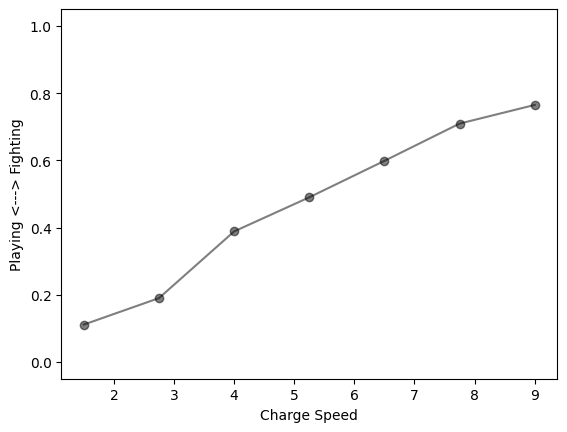

In [12]:
mean_judgement = pd.DataFrame(experiment_df.groupby('chargeSpeed')['is_fight'].mean().reset_index())
plt.plot(mean_judgement['chargeSpeed'], mean_judgement['is_fight'], color='black', marker='o', alpha=0.5)
plt.ylim(-0.05, 1.05)
plt.xlabel('Charge Speed')
plt.ylabel('Playing <---> Fighting')

In [13]:
mean_judgement

,chargeSpeed,is_fight
0,1.50,0.111111
1,2.75,0.189922
2,4.00,0.388372
3,5.25,0.489922
4,6.50,0.598450
5,7.75,0.709302
6,9.00,0.764858


Text(0, 0.5, 'Playing <---> Fighting')

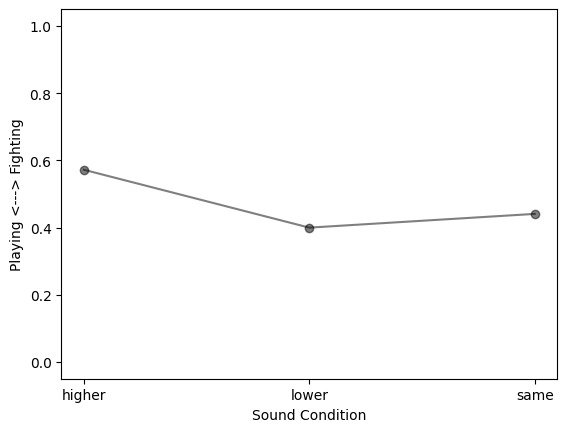

In [14]:
mean_judgementby_sound = pd.DataFrame(experiment_df.groupby('soundCondition')['is_fight'].mean().reset_index())
plt.plot(mean_judgementby_sound['soundCondition'], mean_judgementby_sound['is_fight'], color='black', marker='o', alpha=0.5)
plt.ylim(-0.05, 1.05)
plt.xlabel('Sound Condition')
plt.ylabel('Playing <---> Fighting')

In [15]:
mean_judgementby_sound

,soundCondition,is_fight
0,higher,0.571921
1,lower,0.399655
2,same,0.440568


In [16]:
id_mean = experiment_df.groupby(['id', 'soundCondition', 'chargeSpeed'])[['is_fight', 'confidence']].mean().reset_index()
id_mean.head()

,id,soundCondition,chargeSpeed,is_fight,confidence
0,59948cbdcf1d1700016efa45,higher,1.50,0.166667,70.027452
1,59948cbdcf1d1700016efa45,higher,2.75,0.833333,62.471463
2,59948cbdcf1d1700016efa45,higher,4.00,0.500000,57.830534
3,59948cbdcf1d1700016efa45,higher,5.25,0.900000,60.884440
4,59948cbdcf1d1700016efa45,higher,6.50,0.800000,61.673763


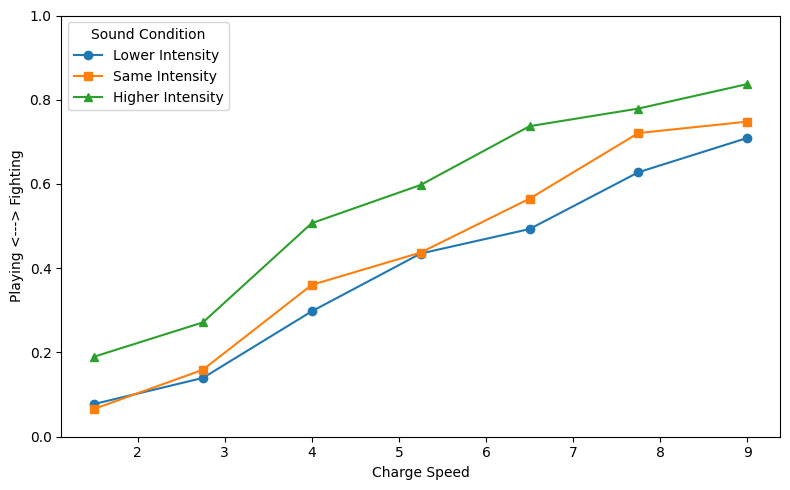

In [ ]:
pythonfig, ax = plt.subplots(figsize=(8, 5))

conditions = [
    ('lower',  'Lower Amplitude',  'o'),
    ('same',   'Same Amplitude',   's'),
    ('higher', 'Higher Amplitude', '^'),
]

for cond, label, marker in conditions:
    sub = experiment_df[experiment_df['soundCondition'] == cond]
    means = sub.groupby('chargeSpeed')['is_fight'].mean().reset_index()
    ax.plot(means['chargeSpeed'], means['is_fight'],
            marker=marker, label=label)

ax.set_xlabel('Charge Speed')
ax.set_ylabel('Playing <---> Fighting')
ax.set_ylim(0, 1)
ax.legend(title='Sound Condition')
plt.tight_layout()
plt.show()

In [19]:
import pingouin as pg
anova = pg.rm_anova(dv='is_fight', within=['soundCondition', 'chargeSpeed'], subject='id', data=id_mean)
print(anova)

                         Source         SS  ddof1  ddof2        MS          F  \
0                soundCondition   4.340000      2     84  2.170000  22.033923   
1                   chargeSpeed  48.349689      6    252  8.058281  92.103511   
2  soundCondition * chargeSpeed   0.463600     12    504  0.038633   1.845678   

          p-unc     p-GG-corr       ng2       eps  
0  2.028830e-08  1.102237e-05  0.070384  0.565245  
1  1.144791e-60  1.837335e-21  0.457548  0.325792  
2  3.878215e-02  1.468119e-01  0.008023  0.232326  


In [20]:
posthoc_sound = pg.pairwise_tests(
    dv='is_fight',
    within='soundCondition',
    subject='id',
    data=id_mean,
    padjust='bonf',
    effsize='cohen'
)
print(posthoc_sound)

         Contrast       A      B  Paired  Parametric         T   dof  \
0  soundCondition  higher  lower    True        True  4.868000  42.0   
1  soundCondition  higher   same    True        True  4.609485  42.0   
2  soundCondition   lower   same    True        True -3.469572  42.0   

  alternative     p-unc    p-corr p-adjust      BF10     cohen  
0   two-sided  0.000016  0.000049     bonf  1259.196  0.914794  
1   two-sided  0.000037  0.000112     bonf   586.817  0.728993  
2   two-sided  0.001218  0.003655     bonf    25.047 -0.256045  


### intermediate speeds

In [21]:
wide = id_mean.pivot_table(index=["id", "chargeSpeed"],
                           columns="soundCondition",
                           values=["is_fight", "confidence"])

diff = pd.DataFrame({
    "is_fight_high_low":   wide[("is_fight",   "higher")] - wide[("is_fight",   "lower")],
    "is_fight_high_same":   wide[("is_fight",   "higher")] - wide[("is_fight",   "same")],
    "is_fight_low_same":   wide[("is_fight",   "lower")] - wide[("is_fight",   "same")],
    "confidence_high_low":   wide[("confidence",   "higher")] - wide[("confidence",   "lower")],
    "confidence_high_same":   wide[("confidence",   "higher")] - wide[("confidence",   "same")],
    "confidence_low_same":   wide[("confidence",   "lower")] - wide[("confidence",   "same")],
}).reset_index()

diff_mean = diff.groupby('chargeSpeed')[['is_fight_high_low', 'is_fight_high_same', 'is_fight_low_same', 'confidence_high_low', 'confidence_high_same', 'confidence_low_same']].mean().reset_index()

Text(0.5, 1.0, 'Higher - Lower')

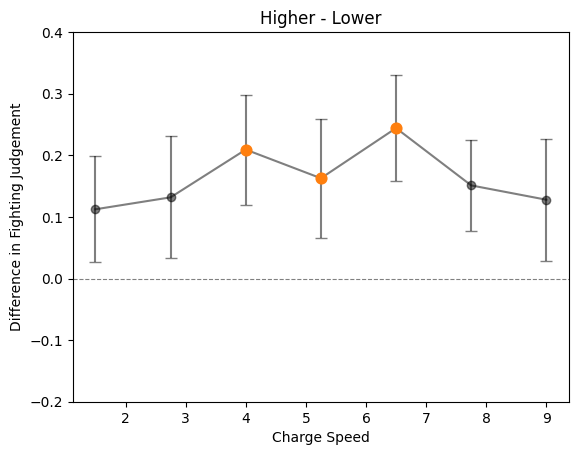

In [22]:
ci = diff.groupby('chargeSpeed')['is_fight_high_low'].agg(['sem', 'count'])
ci['ci95'] = ci['sem'] * stat.t.ppf(0.975, ci['count'] - 1)
diff_mean['ci95'] = ci['ci95'].values

mid = diff_mean['chargeSpeed'].isin([4, 5.25, 6.5])        

plt.axhline(0, color='gray', lw=0.8, ls='--')           
plt.errorbar(diff_mean['chargeSpeed'], diff_mean['is_fight_high_low'],
             yerr=diff_mean['ci95'], color='black', marker='o',
             alpha=0.5, capsize=4)                          
plt.scatter(diff_mean.loc[mid, 'chargeSpeed'], diff_mean.loc[mid, 'is_fight_high_low'],
            color='tab:orange', s=60, zorder=5)

plt.ylim(-0.2, 0.4)
plt.xlabel('Charge Speed')
plt.ylabel('Difference in Fighting Judgement')
plt.title('Higher - Lower')

In [50]:
diff["speed_class"] = diff["chargeSpeed"].isin([4.0, 5.25, 6.5]).map({True: "intermediate", False: "extreme"})

In [51]:
intermediate_extreme = pg.pairwise_tests(
    dv='is_fight_high_low',
    within='speed_class',
    subject='id',
    data=diff,
    padjust='bonf',
    effsize='cohen'
)
print(intermediate_extreme)

      Contrast        A             B  Paired  Parametric         T   dof  \
0  speed_class  extreme  intermediate    True        True -3.227576  42.0   

  alternative     p-unc    BF10     cohen  
0   two-sided  0.002423  13.625 -0.320247  


Text(0.5, 1.0, 'Higher - Same')

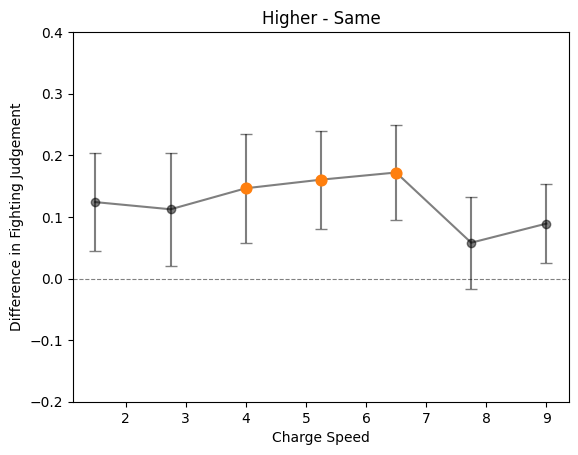

In [23]:
ci = diff.groupby('chargeSpeed')['is_fight_high_same'].agg(['sem', 'count'])
ci['ci95'] = ci['sem'] * stat.t.ppf(0.975, ci['count'] - 1)
diff_mean['ci95'] = ci['ci95'].values

mid = diff_mean['chargeSpeed'].isin([4, 5.25, 6.5])        

plt.axhline(0, color='gray', lw=0.8, ls='--')           
plt.errorbar(diff_mean['chargeSpeed'], diff_mean['is_fight_high_same'],
             yerr=diff_mean['ci95'], color='black', marker='o',
             alpha=0.5, capsize=4)                          
plt.scatter(diff_mean.loc[mid, 'chargeSpeed'], diff_mean.loc[mid, 'is_fight_high_same'],
            color='tab:orange', s=60, zorder=5)

plt.ylim(-0.2, 0.4)
plt.xlabel('Charge Speed')
plt.ylabel('Difference in Fighting Judgement')
plt.title('Higher - Same')

Text(0.5, 1.0, 'Lower - Same')

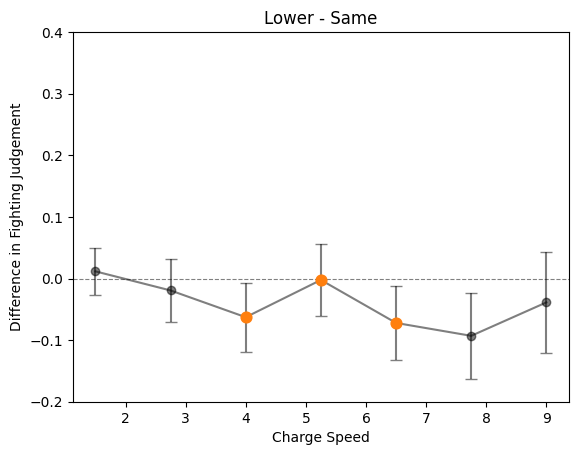

In [24]:
ci = diff.groupby('chargeSpeed')['is_fight_low_same'].agg(['sem', 'count'])
ci['ci95'] = ci['sem'] * stat.t.ppf(0.975, ci['count'] - 1)
diff_mean['ci95'] = ci['ci95'].values

mid = diff_mean['chargeSpeed'].isin([4, 5.25, 6.5])        

plt.axhline(0, color='gray', lw=0.8, ls='--')           
plt.errorbar(diff_mean['chargeSpeed'], diff_mean['is_fight_low_same'],
             yerr=diff_mean['ci95'], color='black', marker='o',
             alpha=0.5, capsize=4)                          
plt.scatter(diff_mean.loc[mid, 'chargeSpeed'], diff_mean.loc[mid, 'is_fight_low_same'],
            color='tab:orange', s=60, zorder=5)

plt.ylim(-0.2, 0.4)
plt.xlabel('Charge Speed')
plt.ylabel('Difference in Fighting Judgement')
plt.title('Lower - Same')

In [25]:
intermediate_speeds_mean = id_mean[id_mean['chargeSpeed'].isin([4, 5.25, 6.5])].groupby(['id', 'soundCondition'])[['is_fight']].mean().reset_index()
intermediate_speeds_mean = intermediate_speeds_mean[intermediate_speeds_mean['soundCondition'] != 'same']
extreme_speeds_mean = id_mean[~id_mean['chargeSpeed'].isin([4, 5.25, 6.5])].groupby(['id', 'soundCondition'])[['is_fight']].mean().reset_index()
extreme_speeds_mean = extreme_speeds_mean[extreme_speeds_mean['soundCondition'] != 'same']

In [26]:
intermediate = pg.pairwise_tests(
    dv='is_fight',
    within='soundCondition',
    subject='id',
    data=intermediate_speeds_mean,
    effsize='cohen'
)
print(intermediate)

         Contrast       A      B  Paired  Parametric         T   dof  \
0  soundCondition  higher  lower    True        True  5.581377  42.0   

  alternative     p-unc       BF10     cohen  
0   two-sided  0.000002  1.095e+04  0.938434  


In [27]:
extreme = pg.pairwise_tests(
    dv='is_fight',
    within='soundCondition',
    subject='id',
    data=extreme_speeds_mean,
    effsize='cohen'
)
print(extreme)

         Contrast       A      B  Paired  Parametric         T   dof  \
0  soundCondition  higher  lower    True        True  3.824281  42.0   

  alternative     p-unc    BF10     cohen  
0   two-sided  0.000428  63.863  0.787189  


### confidence-weighted judgement

In [78]:
c = experiment_df["confidence"] / 100
experiment_df["weighted_is_fight"] = np.where(
    experiment_df["is_fight"] == 1,
    0.5 + c * 0.5,
    0.5 - c * 0.5,
)

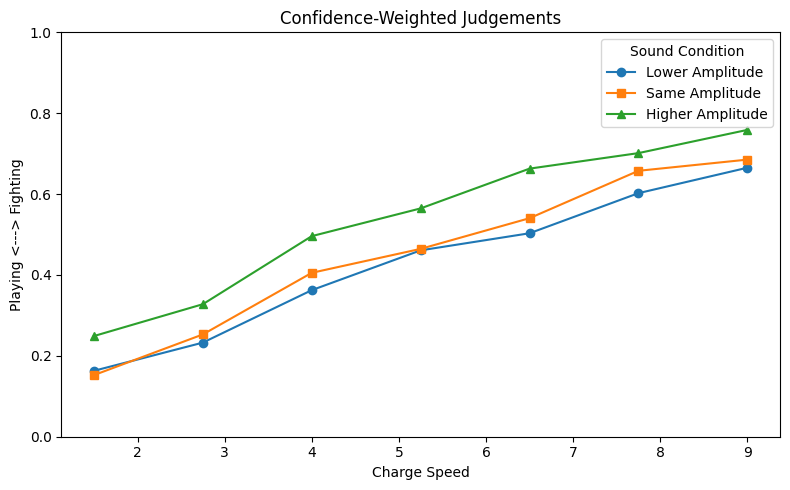

In [79]:
pythonfig, ax = plt.subplots(figsize=(8, 5))

conditions = [
    ('lower',  'Lower Amplitude',  'o'),
    ('same',   'Same Amplitude',   's'),
    ('higher', 'Higher Amplitude', '^'),
]

for cond, label, marker in conditions:
    sub = experiment_df[experiment_df['soundCondition'] == cond]
    means = sub.groupby('chargeSpeed')['weighted_is_fight'].mean().reset_index()
    ax.plot(means['chargeSpeed'], means['weighted_is_fight'],
            marker=marker, label=label)

ax.set_xlabel('Charge Speed')
ax.set_ylabel('Playing <---> Fighting')
ax.set_ylim(0, 1)
ax.set_title('Confidence-Weighted Judgements')
ax.legend(title='Sound Condition')
plt.tight_layout()
plt.show()

In [83]:
id_mean = experiment_df.groupby(['id', 'soundCondition', 'chargeSpeed'])[['weighted_is_fight']].mean().reset_index()

In [84]:
anova = pg.rm_anova(dv='weighted_is_fight', within=['soundCondition', 'chargeSpeed'], subject='id', data=id_mean)
print(anova)

                         Source         SS  ddof1  ddof2        MS          F  \
0                soundCondition   2.016654      2     84  1.008327  23.994889   
1                   chargeSpeed  28.369955      6    252  4.728326  97.123968   
2  soundCondition * chargeSpeed   0.160006     12    504  0.013334   1.636894   

          p-unc     p-GG-corr       ng2       eps  
0  5.715280e-09  4.168589e-06  0.064888  0.580102  
1  1.152270e-62  7.395331e-19  0.493972  0.271823  
2  7.802130e-02  1.987716e-01  0.005475  0.177392  


In [85]:
posthoc_sound = pg.pairwise_tests(
    dv='weighted_is_fight',
    within='soundCondition',
    subject='id',
    data=id_mean,
    padjust='bonf',
    effsize='cohen'
)
print(posthoc_sound)

         Contrast       A      B  Paired  Parametric         T   dof  \
0  soundCondition  higher  lower    True        True  5.044431  42.0   
1  soundCondition  higher   same    True        True  5.003995  42.0   
2  soundCondition   lower   same    True        True -2.969175  42.0   

  alternative     p-unc    p-corr p-adjust      BF10     cohen  
0   two-sided  0.000009  0.000028     bonf  2135.348  0.872929  
1   two-sided  0.000011  0.000032     bonf  1891.039  0.724345  
2   two-sided  0.004917  0.014752     bonf     7.331 -0.210149  


## confidence

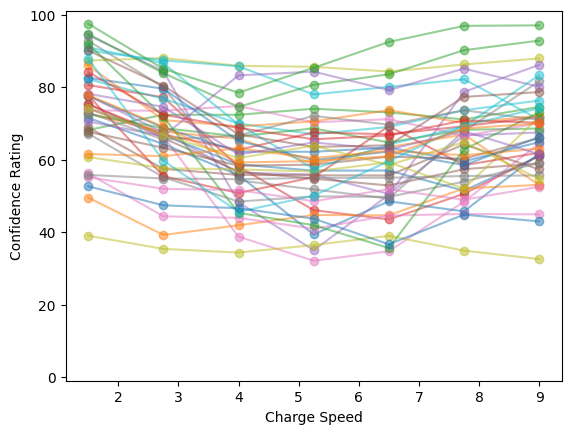

In [28]:
for id in ids:
    df = experiment_df[experiment_df['id'] == id]
    mean_rating_per_speed = pd.DataFrame(df.groupby('chargeSpeed')['confidence'].mean().reset_index())
    plt.plot(mean_rating_per_speed['chargeSpeed'], mean_rating_per_speed['confidence'], marker='o', alpha=0.5)
    plt.ylim(-1, 101)
    plt.xlabel('Charge Speed')
    plt.ylabel('Confidence Rating')

Text(0, 0.5, 'Confidence Rating')

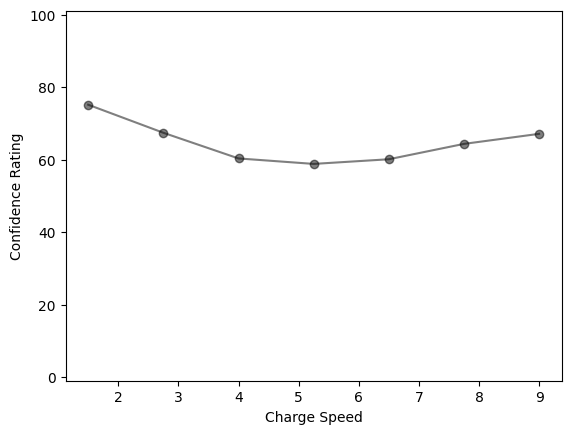

In [29]:
mean_confidence = pd.DataFrame(experiment_df.groupby('chargeSpeed')['confidence'].mean().reset_index())
plt.plot(mean_confidence['chargeSpeed'], mean_confidence['confidence'], color='black', marker='o', alpha=0.5)
plt.ylim(-1, 101)
plt.xlabel('Charge Speed')
plt.ylabel('Confidence Rating')

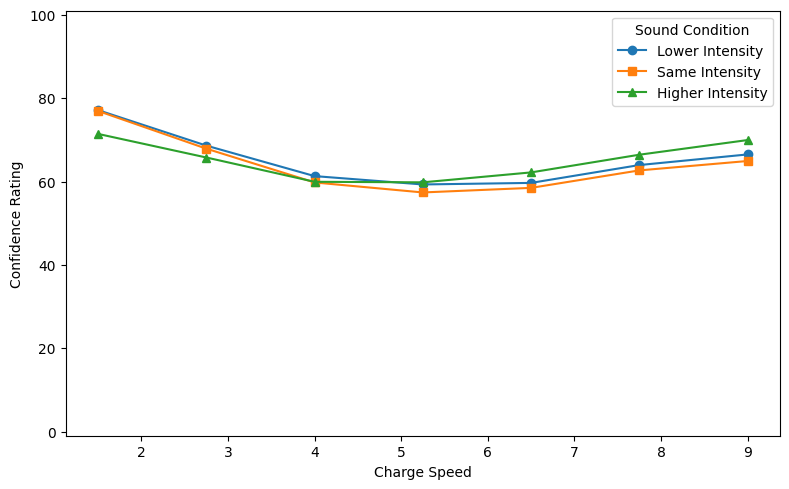

In [ ]:
pythonfig, ax = plt.subplots(figsize=(8, 5))

conditions = [
    ('lower',  'Lower Amplitude',  'o'),
    ('same',   'Same Amplitude',   's'),
    ('higher', 'Higher Amplitude', '^'),
]

for cond, label, marker in conditions:
    sub = experiment_df[experiment_df['soundCondition'] == cond]
    means = sub.groupby('chargeSpeed')['confidence'].mean().reset_index()
    ax.plot(means['chargeSpeed'], means['confidence'],
            marker=marker, label=label)

ax.set_xlabel('Charge Speed')
ax.set_ylabel('Confidence Rating')
ax.set_ylim(-1, 101)
ax.legend(title='Sound Condition')
plt.tight_layout()
plt.show()

In [31]:
anova = pg.rm_anova(dv='confidence', within=['soundCondition', 'chargeSpeed'], subject='id', data=id_mean)
print(anova)

                         Source            SS  ddof1  ddof2           MS  \
0                soundCondition    261.259113      2     84   130.629556   
1                   chargeSpeed  25470.030932      6    252  4245.005155   
2  soundCondition * chargeSpeed   2222.890865     12    504   185.240905   

           F         p-unc     p-GG-corr       ng2       eps  
0   2.429954  9.420715e-02  1.025197e-01  0.001468  0.865870  
1  28.719218  4.216442e-26  1.636889e-10  0.125328  0.345078  
2   4.027857  5.448907e-06  9.769569e-03  0.012351  0.241565  


In [32]:
posthoc_interaction = pg.pairwise_tests(
    dv='confidence',
    within=['soundCondition', 'chargeSpeed'],
    subject='id',
    data=id_mean,
    padjust='bonf',
    effsize='cohen'
)
print(posthoc_interaction)

                        Contrast soundCondition       A      B Paired  \
0                 soundCondition              -  higher  lower   True   
1                 soundCondition              -  higher   same   True   
2                 soundCondition              -   lower   same   True   
3                    chargeSpeed              -     1.5   2.75   True   
4                    chargeSpeed              -     1.5    4.0   True   
..                           ...            ...     ...    ...    ...   
82  soundCondition * chargeSpeed           same    5.25   7.75   True   
83  soundCondition * chargeSpeed           same    5.25    9.0   True   
84  soundCondition * chargeSpeed           same     6.5   7.75   True   
85  soundCondition * chargeSpeed           same     6.5    9.0   True   
86  soundCondition * chargeSpeed           same    7.75    9.0   True   

   Parametric         T   dof alternative         p-unc        p-corr  \
0        True -0.272537  42.0   two-sided  7.86544

### intermediate confidence

Text(0.5, 1.0, 'Higher - Lower')

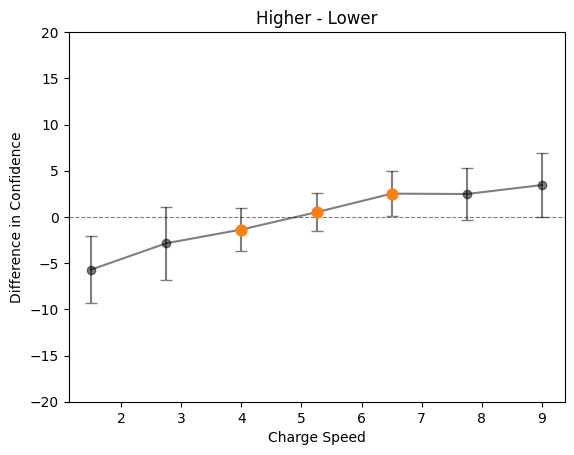

In [33]:
ci = diff.groupby('chargeSpeed')['confidence_high_low'].agg(['sem', 'count'])
ci['ci95'] = ci['sem'] * stat.t.ppf(0.975, ci['count'] - 1)
diff_mean['ci95'] = ci['ci95'].values

mid = diff_mean['chargeSpeed'].isin([4, 5.25, 6.5])        

plt.axhline(0, color='gray', lw=0.8, ls='--')           
plt.errorbar(diff_mean['chargeSpeed'], diff_mean['confidence_high_low'],
             yerr=diff_mean['ci95'], color='black', marker='o',
             alpha=0.5, capsize=4)                          
plt.scatter(diff_mean.loc[mid, 'chargeSpeed'], diff_mean.loc[mid, 'confidence_high_low'],
            color='tab:orange', s=60, zorder=5)

plt.ylim(-20, 20)
plt.xlabel('Charge Speed')
plt.ylabel('Difference in Confidence')
plt.title('Higher - Lower')

In [52]:
intermediate_extreme = pg.pairwise_tests(
    dv='confidence_high_low',
    within='speed_class',
    subject='id',
    data=diff,
    padjust='bonf',
    effsize='cohen'
)
print(intermediate_extreme)

      Contrast        A             B  Paired  Parametric         T   dof  \
0  speed_class  extreme  intermediate    True        True -1.118299  42.0   

  alternative     p-unc   BF10     cohen  
0   two-sided  0.269795  0.296 -0.253259  


Text(0.5, 1.0, 'Higher - Same')

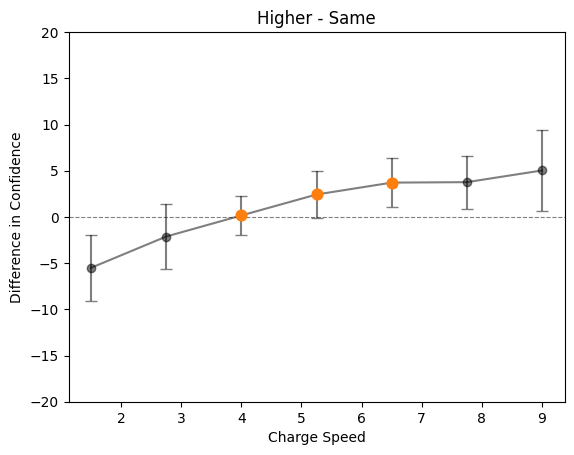

In [34]:
ci = diff.groupby('chargeSpeed')['confidence_high_same'].agg(['sem', 'count'])
ci['ci95'] = ci['sem'] * stat.t.ppf(0.975, ci['count'] - 1)
diff_mean['ci95'] = ci['ci95'].values

mid = diff_mean['chargeSpeed'].isin([4, 5.25, 6.5])        

plt.axhline(0, color='gray', lw=0.8, ls='--')           
plt.errorbar(diff_mean['chargeSpeed'], diff_mean['confidence_high_same'],
             yerr=diff_mean['ci95'], color='black', marker='o',
             alpha=0.5, capsize=4)                          
plt.scatter(diff_mean.loc[mid, 'chargeSpeed'], diff_mean.loc[mid, 'confidence_high_same'],
            color='tab:orange', s=60, zorder=5)

plt.ylim(-20, 20)
plt.xlabel('Charge Speed')
plt.ylabel('Difference in Confidence')
plt.title('Higher - Same')

Text(0.5, 1.0, 'Lower - Same')

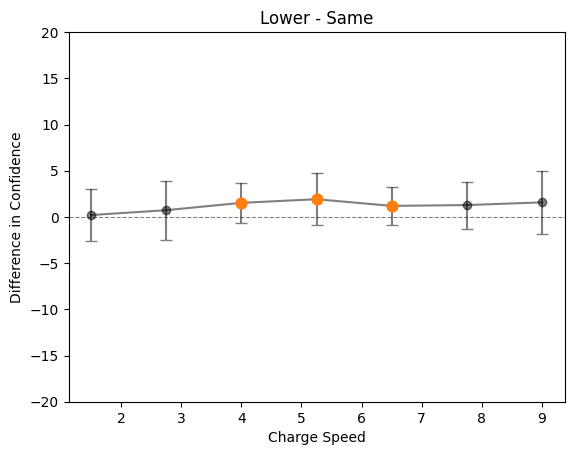

In [35]:
ci = diff.groupby('chargeSpeed')['confidence_low_same'].agg(['sem', 'count'])
ci['ci95'] = ci['sem'] * stat.t.ppf(0.975, ci['count'] - 1)
diff_mean['ci95'] = ci['ci95'].values

mid = diff_mean['chargeSpeed'].isin([4, 5.25, 6.5])        

plt.axhline(0, color='gray', lw=0.8, ls='--')           
plt.errorbar(diff_mean['chargeSpeed'], diff_mean['confidence_low_same'],
             yerr=diff_mean['ci95'], color='black', marker='o',
             alpha=0.5, capsize=4)                          
plt.scatter(diff_mean.loc[mid, 'chargeSpeed'], diff_mean.loc[mid, 'confidence_low_same'],
            color='tab:orange', s=60, zorder=5)

plt.ylim(-20, 20)
plt.xlabel('Charge Speed')
plt.ylabel('Difference in Confidence')
plt.title('Lower - Same')

In [36]:
intermediate_confidence_mean = id_mean[id_mean['chargeSpeed'].isin([4, 5.25, 6.5])].groupby(['id', 'soundCondition'])[['confidence']].mean().reset_index()
intermediate_confidence_mean = intermediate_confidence_mean[intermediate_confidence_mean['soundCondition'] != 'same']
slow_confidence_mean = id_mean[id_mean['chargeSpeed'].isin([1.5, 2.75])].groupby(['id', 'soundCondition'])[['confidence']].mean().reset_index()
fast_confidence_mean = id_mean[id_mean['chargeSpeed'].isin([7.75, 9])].groupby(['id', 'soundCondition'])[['confidence']].mean().reset_index()
slow_confidence_mean = slow_confidence_mean[slow_confidence_mean['soundCondition'] != 'same']
fast_confidence_mean = fast_confidence_mean[fast_confidence_mean['soundCondition'] != 'same']

In [37]:
intermediate = pg.pairwise_tests(
    dv='confidence',
    within='soundCondition',
    subject='id',
    data=intermediate_confidence_mean,
    effsize='cohen'
)
print(intermediate)

         Contrast       A      B  Paired  Parametric         T   dof  \
0  soundCondition  higher  lower    True        True  0.824289  42.0   

  alternative     p-unc   BF10     cohen  
0   two-sided  0.414432  0.227  0.043774  


In [38]:
slow = pg.pairwise_tests(
    dv='confidence',
    within='soundCondition',
    subject='id',
    data=slow_confidence_mean,
    effsize='cohen'
)
print(slow)

         Contrast       A      B  Paired  Parametric         T   dof  \
0  soundCondition  higher  lower    True        True -2.693658  42.0   

  alternative     p-unc   BF10     cohen  
0   two-sided  0.010113  3.934 -0.296906  


In [39]:
fast = pg.pairwise_tests(
    dv='confidence',
    within='soundCondition',
    subject='id',
    data=fast_confidence_mean,
    effsize='cohen'
)
print(fast)

         Contrast       A      B  Paired  Parametric         T   dof  \
0  soundCondition  higher  lower    True        True  2.801039  42.0   

  alternative     p-unc  BF10     cohen  
0   two-sided  0.007669  4.99  0.222897  


# main analysis - within sound conditions

## ISI check

In [40]:
isi = pd.DataFrame(experiment_df.groupby(['id', 'soundCondition'])['ISI_ms'].mean()).reset_index()
aov = pg.rm_anova(data=isi, dv='ISI_ms', within='soundCondition', subject='id')
print(aov)

           Source  ddof1  ddof2        F     p-unc      ng2       eps
0  soundCondition      2     84  2.66683  0.075352  0.02726  0.973556


## judgement

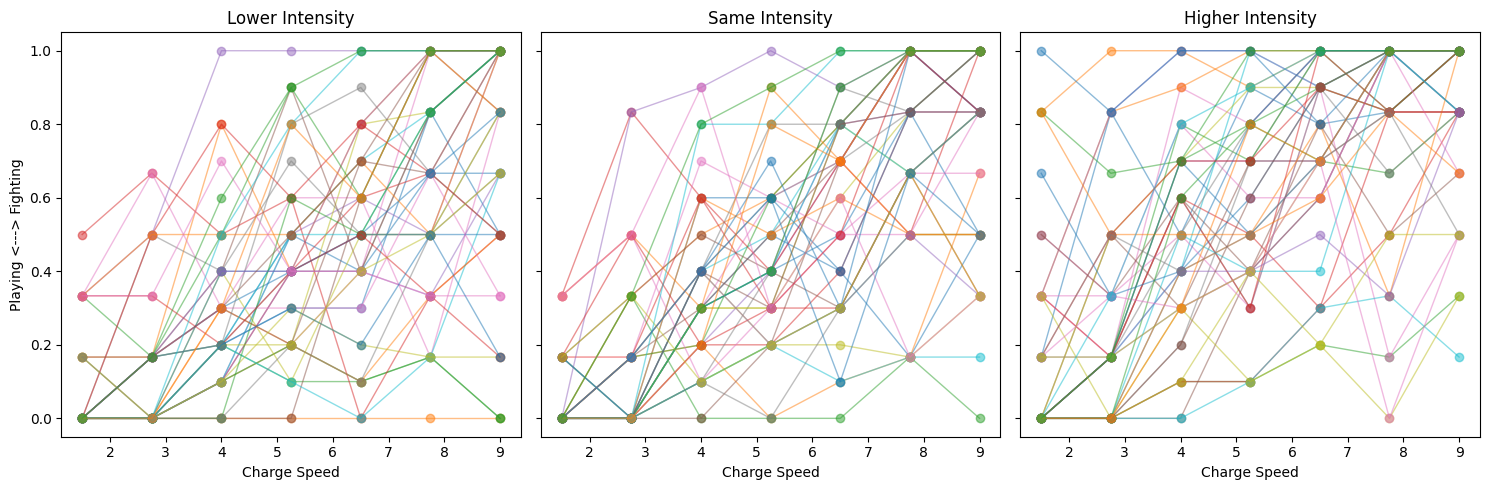

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

conditions = [
    ('lower',  'Lower Amplitude',  'o'),
    ('same',   'Same Amplitude',   'o'),
    ('higher', 'Higher Amplitude', 'o'),
]

for ax, (cond, title, marker) in zip(axes, conditions):
    sub = experiment_df[experiment_df['soundCondition'] == cond]

    # One line per participant
    for pid in ids:
        p = sub[sub['id'] == pid]
        means = p.groupby('chargeSpeed')['is_fight'].mean().reset_index()
        ax.plot(means['chargeSpeed'], means['is_fight'],
                marker=marker, alpha=0.5, linewidth=1)

    ax.set_title(title)
    ax.set_xlabel('Charge Speed')


axes[0].set_ylabel('Playing <---> Fighting')
plt.tight_layout()
plt.show()

In [42]:
per_pid = (experiment_df
           .groupby(['id', 'soundCondition', 'chargeSpeed'])['is_fight']
           .mean()
           .reset_index())

order = ['lower', 'same', 'higher']
speeds = sorted(per_pid['chargeSpeed'].unique())
ids = per_pid['id'].unique()

### UNCOMMENT TO PLOT PER PARTICIPANT
# for pid in ids:
#     pdat = per_pid[per_pid['id'] == pid]
#     fig, axes = plt.subplots(1, len(speeds), figsize=(20, 5), sharey=True)

#     for ax, speed in zip(axes, speeds):
#         sub = pdat[pdat['chargeSpeed'] == speed]
#         sns.pointplot(data=sub, x='soundCondition', y='is_fight',
#                       order=order, ax=ax, join=False, color='tab:blue')
#         ax.set_title(f'Speed {speed}')
#         ax.set_xlabel('')
#         ax.set_ylim(-0.05, 1.05)
#         ax.tick_params(axis='x', rotation=45)

#     axes[0].set_ylabel('Playing <---> Fighting')
#     fig.supxlabel(pid)
#     plt.tight_layout()
#     plt.show()

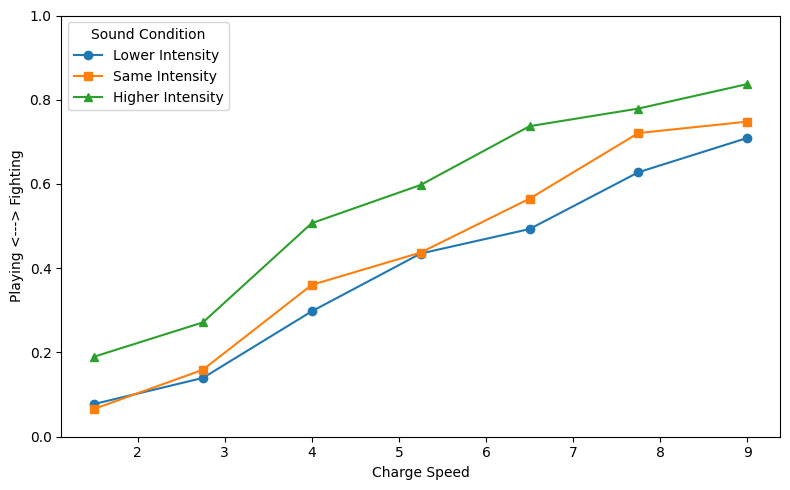

In [ ]:
pythonfig, ax = plt.subplots(figsize=(8, 5))

conditions = [
    ('lower',  'Lower Amplitude',  'o'),
    ('same',   'Same Amplitude',   's'),
    ('higher', 'Higher Amplitude', '^'),
]

for cond, label, marker in conditions:
    sub = experiment_df[experiment_df['soundCondition'] == cond]
    means = sub.groupby('chargeSpeed')['is_fight'].mean().reset_index()
    ax.plot(means['chargeSpeed'], means['is_fight'],
            marker=marker, label=label)

ax.set_xlabel('Charge Speed')
ax.set_ylabel('Playing <---> Fighting')
ax.set_ylim(0, 1)
ax.legend(title='Sound Condition')
plt.tight_layout()
plt.show()

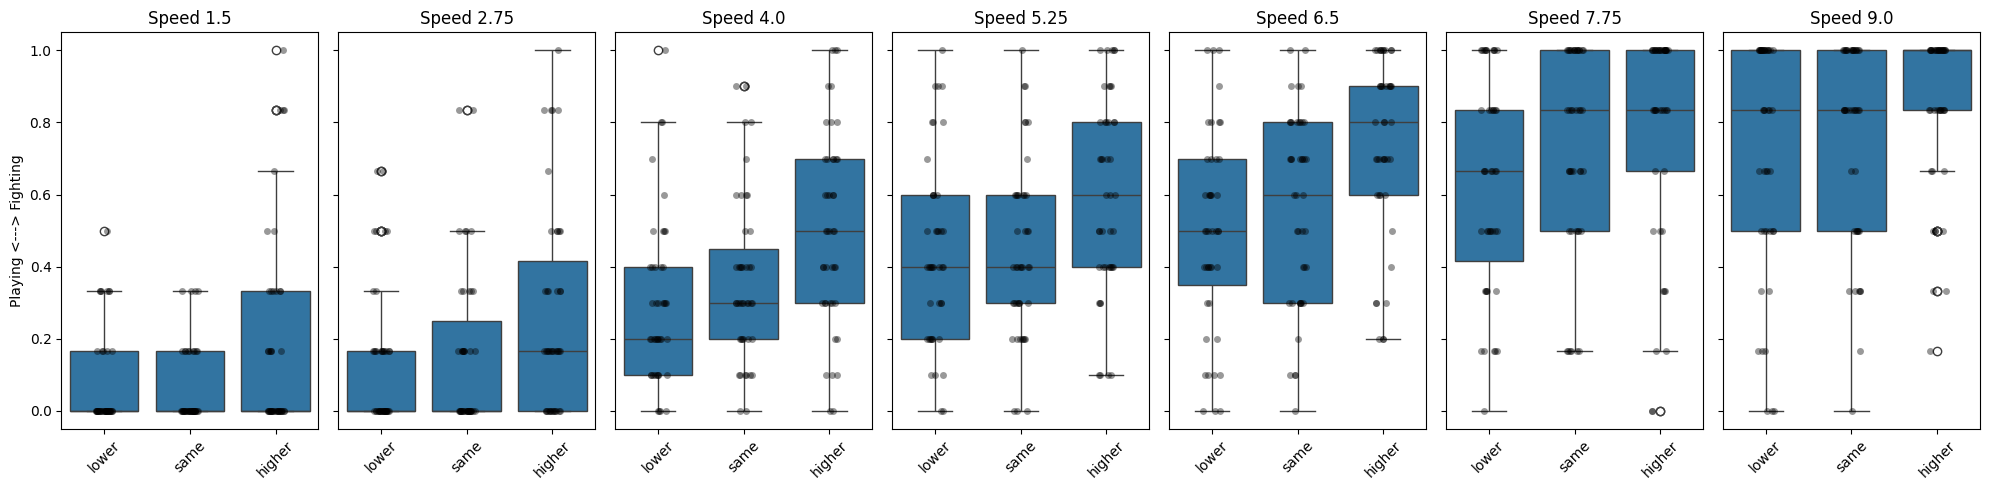

In [44]:
per_pid = (experiment_df
           .groupby(['id', 'soundCondition', 'chargeSpeed'])['is_fight']
           .mean()
           .reset_index())

order = ['lower', 'same', 'higher']
speeds = sorted(per_pid['chargeSpeed'].unique())

fig, axes = plt.subplots(1, len(speeds), figsize=(20, 5), sharey=True)

for ax, speed in zip(axes, speeds):
    sub = per_pid[per_pid['chargeSpeed'] == speed]
    sns.boxplot(data=sub, x='soundCondition', y='is_fight', order=order, ax=ax)
    sns.stripplot(data=sub, x='soundCondition', y='is_fight',
                  order=order, ax=ax, color='black', alpha=0.4, jitter=True)
    ax.set_title(f'Speed {speed}')
    ax.set_xlabel('')
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(axis='x', rotation=45)

axes[0].set_ylabel('Playing <---> Fighting')
plt.tight_layout()
plt.show()

## confidence

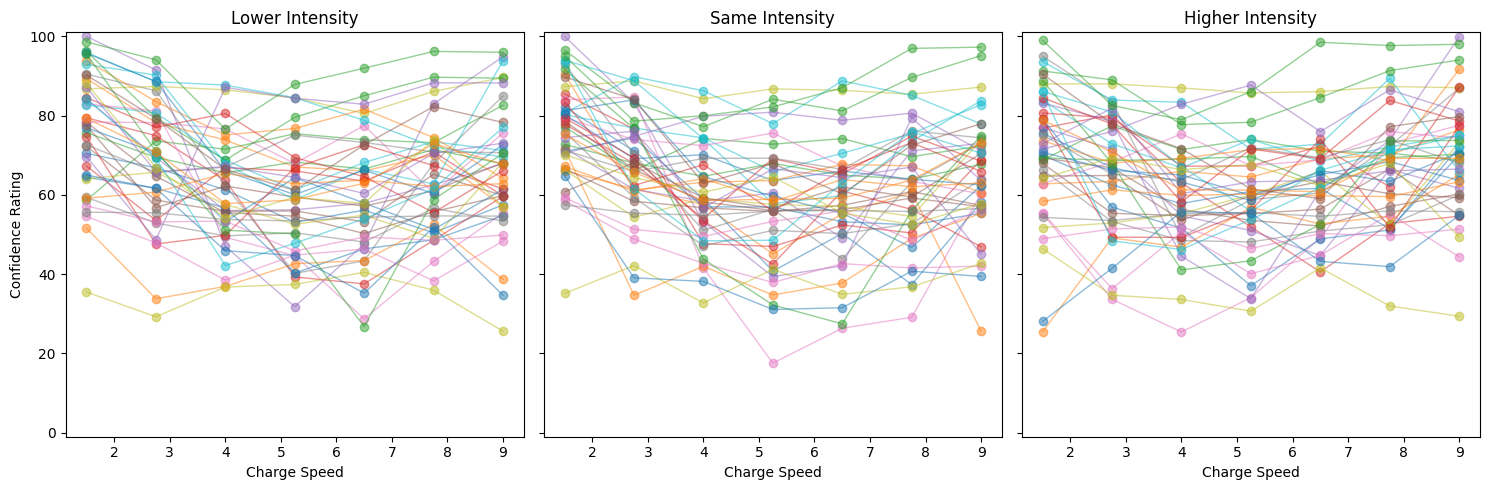

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

conditions = [
    ('lower',  'Lower Amplitude',  'o'),
    ('same',   'Same Amplitude',   'o'),
    ('higher', 'Higher Amplitude', 'o'),
]

for ax, (cond, title, marker) in zip(axes, conditions):
    sub = experiment_df[experiment_df['soundCondition'] == cond]
    for pid in ids:
        p = sub[sub['id'] == pid]
        means = p.groupby('chargeSpeed')['confidence'].mean().reset_index()
        ax.plot(means['chargeSpeed'], means['confidence'],
                marker=marker, alpha=0.5, linewidth=1)

    ax.set_title(title)
    ax.set_xlabel('Charge Speed')
    ax.set_ylim(-1, 101)


axes[0].set_ylabel('Confidence Rating')
plt.tight_layout()
plt.show()

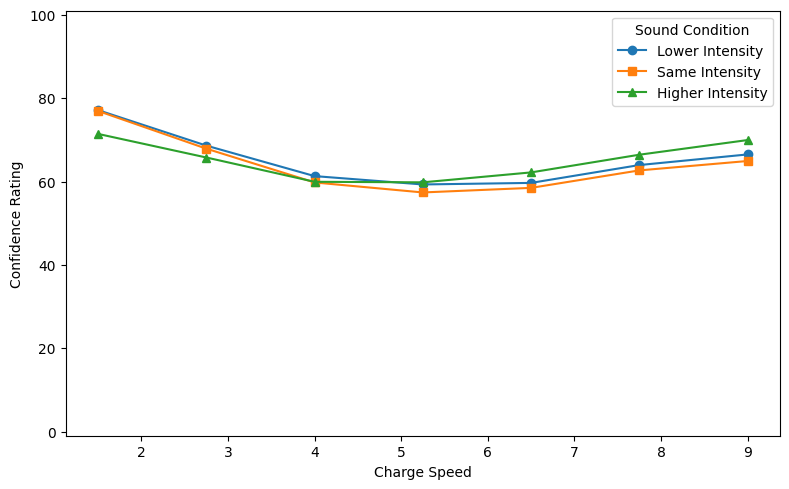

In [ ]:
pythonfig, ax = plt.subplots(figsize=(8, 5))

conditions = [
    ('lower',  'Lower Amplitude',  'o'),
    ('same',   'Same Amplitude',   's'),
    ('higher', 'Higher Amplitude', '^'),
]

for cond, label, marker in conditions:
    sub = experiment_df[experiment_df['soundCondition'] == cond]
    means = sub.groupby('chargeSpeed')['confidence'].mean().reset_index()
    ax.plot(means['chargeSpeed'], means['confidence'],
            marker=marker, label=label)

ax.set_xlabel('Charge Speed')
ax.set_ylabel('Confidence Rating')
ax.set_ylim(-1, 101)
ax.legend(title='Sound Condition')
plt.tight_layout()
plt.show()

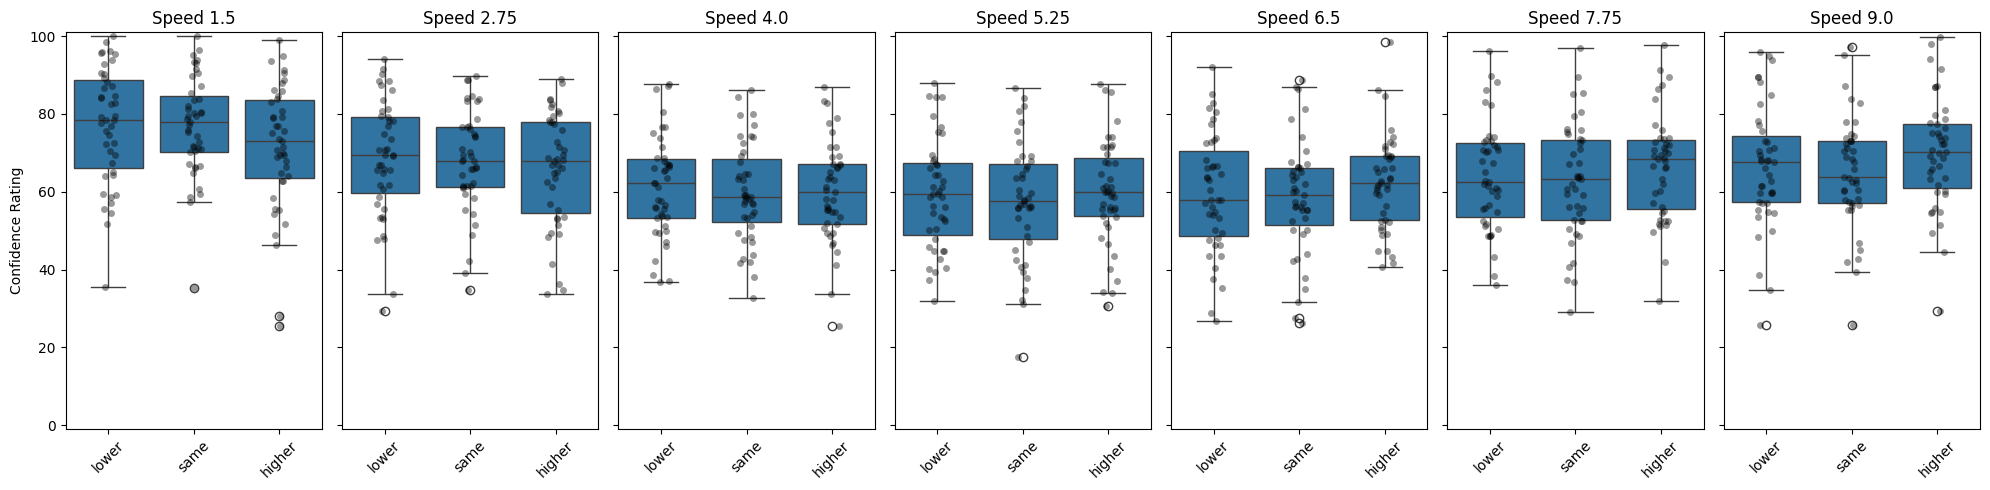

In [47]:
per_pid = (experiment_df
           .groupby(['id', 'soundCondition', 'chargeSpeed'])['confidence']
           .mean()
           .reset_index())

order = ['lower', 'same', 'higher']
speeds = sorted(per_pid['chargeSpeed'].unique())

fig, axes = plt.subplots(1, len(speeds), figsize=(20, 5), sharey=True)

for ax, speed in zip(axes, speeds):
    sub = per_pid[per_pid['chargeSpeed'] == speed]
    sns.boxplot(data=sub, x='soundCondition', y='confidence', order=order, ax=ax)
    sns.stripplot(data=sub, x='soundCondition', y='confidence',
                  order=order, ax=ax, color='black', alpha=0.4, jitter=True)
    ax.set_title(f'Speed {speed}')
    ax.set_xlabel('')
    ax.set_ylim(-1, 101)
    ax.tick_params(axis='x', rotation=45)

axes[0].set_ylabel('Confidence Rating')
plt.tight_layout()
plt.show()

# Group analysis by sound awareness

In [57]:
aware_id = []
non_aware_id = []
for i in sub_id:
    sub_demo = demographic_df[demographic_df['subject_id'] == i]
    if 'louder' in sub_demo['sound_awareness'].values[0] and 'softer' in sub_demo['sound_awareness'].values[0]:
        aware_id.append(i)
    else:
        non_aware_id.append(i)

In [58]:
aware_df = experiment_df[experiment_df['subject_id'].isin(aware_id)]
non_aware_df = experiment_df[experiment_df['subject_id'].isin(non_aware_id)]

In [92]:
experiment_df["sound_aware"] = experiment_df["subject_id"].isin(aware_id).astype(int)
experiment_df.to_csv('../exp1_experiment_data.csv', index=False)

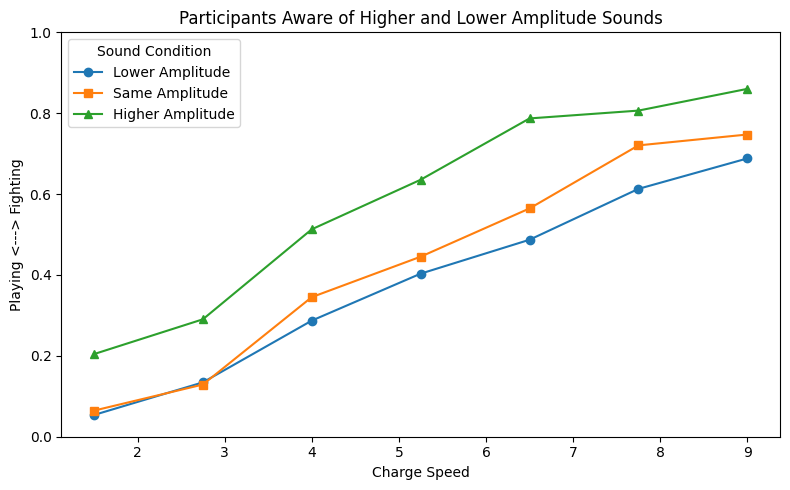

In [63]:
pythonfig, ax = plt.subplots(figsize=(8, 5))

conditions = [
    ('lower',  'Lower Amplitude',  'o'),
    ('same',   'Same Amplitude',   's'),
    ('higher', 'Higher Amplitude', '^'),
]

for cond, label, marker in conditions:
    sub = aware_df[aware_df['soundCondition'] == cond]
    means = sub.groupby('chargeSpeed')['is_fight'].mean().reset_index()
    ax.plot(means['chargeSpeed'], means['is_fight'],
            marker=marker, label=label)

ax.set_xlabel('Charge Speed')
ax.set_ylabel('Playing <---> Fighting')
ax.set_ylim(0, 1)
ax.set_title('Participants Aware of Higher and Lower Amplitude Sounds')
ax.legend(title='Sound Condition')
plt.tight_layout()
plt.show()

In [86]:
aware_id_mean = aware_df.groupby(['id', 'soundCondition', 'chargeSpeed'])[['is_fight']].mean().reset_index()

In [87]:
anova = pg.rm_anova(dv='is_fight', within=['soundCondition', 'chargeSpeed'], subject='id', data=aware_id_mean)
print(anova)

                         Source         SS  ddof1  ddof2        MS          F  \
0                soundCondition   4.923280      2     60  2.461640  21.176283   
1                   chargeSpeed  36.072538      6    180  6.012090  75.569554   
2  soundCondition * chargeSpeed   0.397293     12    360  0.033108   1.542794   

          p-unc     p-GG-corr       ng2       eps  
0  1.100463e-07  3.312392e-05  0.109939  0.559010  
1  1.437592e-46  2.165012e-17  0.475070  0.339462  
2  1.068211e-01  2.125499e-01  0.009869  0.228944  


In [88]:
posthoc_sound = pg.pairwise_tests(
    dv='is_fight',
    within='soundCondition',
    subject='id',
    data=aware_id_mean,
    padjust='bonf',
    effsize='cohen'
)
print(posthoc_sound)

         Contrast       A      B  Paired  Parametric         T   dof  \
0  soundCondition  higher  lower    True        True  4.751511  30.0   
1  soundCondition  higher   same    True        True  4.536580  30.0   
2  soundCondition   lower   same    True        True -3.466626  30.0   

  alternative     p-unc    p-corr p-adjust     BF10     cohen  
0   two-sided  0.000047  0.000141     bonf  511.591  1.147466  
1   two-sided  0.000086  0.000258     bonf  295.716  0.900720  
2   two-sided  0.001613  0.004840     bonf   21.547 -0.323967  


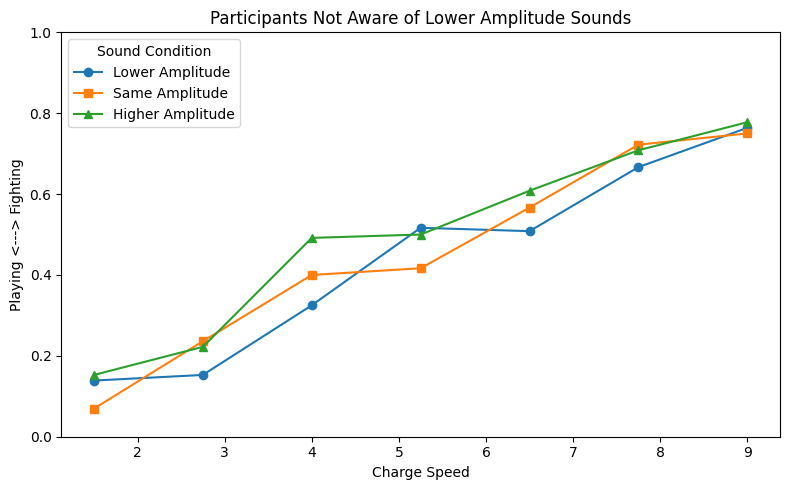

In [64]:
pythonfig, ax = plt.subplots(figsize=(8, 5))

conditions = [
    ('lower',  'Lower Amplitude',  'o'),
    ('same',   'Same Amplitude',   's'),
    ('higher', 'Higher Amplitude', '^'),
]

for cond, label, marker in conditions:
    sub = non_aware_df[non_aware_df['soundCondition'] == cond]
    means = sub.groupby('chargeSpeed')['is_fight'].mean().reset_index()
    ax.plot(means['chargeSpeed'], means['is_fight'],
            marker=marker, label=label)

ax.set_xlabel('Charge Speed')
ax.set_ylabel('Playing <---> Fighting')
ax.set_ylim(0, 1)
ax.set_title('Participants Not Aware of Lower Amplitude Sounds')
ax.legend(title='Sound Condition')
plt.tight_layout()
plt.show()

In [89]:
non_aware_id_mean = non_aware_df.groupby(['id', 'soundCondition', 'chargeSpeed'])[['is_fight']].mean().reset_index()

In [90]:
anova = pg.rm_anova(dv='is_fight', within=['soundCondition', 'chargeSpeed'], subject='id', data=non_aware_id_mean)
print(anova)

                         Source         SS  ddof1  ddof2        MS          F  \
0                soundCondition   0.142363      2     22  0.071182   2.736103   
1                   chargeSpeed  12.384929      6     66  2.064155  17.878900   
2  soundCondition * chargeSpeed   0.274674     12    132  0.022889   1.155061   

          p-unc  p-GG-corr       ng2       eps  
0  8.686019e-02   0.108378  0.008596  0.710840  
1  3.471690e-12   0.000083  0.429984  0.282553  
2  3.222031e-01   0.326705  0.016454  0.134848  
